# Grundlagen der Künstlichen Intelligenz.
# Exercise 1. Data Processing / Cleaning

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 1 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

### Cereal Dataset: Cleaning and Visualization

1. Load the `cereals.csv` dataset into a Pandas DataFrame.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Aux/cereal.csv")
print(df)

                         name mfr type  calories  protein  fat  sodium  fiber  \
0                   100% Bran   N    C        70        4    1     130   10.0   
1           100% Natural Bran   Q    C       120        3    5      15    2.0   
2                    All-Bran   K    C        70        4    1     260    9.0   
3   All-Bran with Extra Fiber   K    C        50        4    0     140   14.0   
4              Almond Delight   R    C       110        2    2     200    1.0   
..                        ...  ..  ...       ...      ...  ...     ...    ...   
72                    Triples   G    C       110        2    1     250    0.0   
73                       Trix   G    C       110        1    1     140    0.0   
74                 Wheat Chex   R    C       100        3    1     230    3.0   
75                   Wheaties   G    C       100        3    1     200    3.0   
76        Wheaties Honey Gold   G    C       110        2    1     200    1.0   

    carbo  sugars  potass  

2. Check for missing values in the DataFrame.

Note: Make sure that each column fullfills it.

In [2]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 name        0
mfr         0
type        0
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       0
sugars      0
potass      0
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64


3. If any missing values are found, handle them appropriately (e.g., by removing rows, using
`dropna()`).

In [3]:
df = df.dropna()

4. Verify that all numerical columns contain numerical values.

In [4]:
print("Data types:\n", df.dtypes)

Data types:
 name            str
mfr             str
type            str
calories      int64
protein       int64
fat           int64
sodium        int64
fiber       float64
carbo       float64
sugars        int64
potass        int64
vitamins      int64
shelf         int64
weight      float64
cups        float64
rating      float64
dtype: object


5. If any non-numerical values are found in numerical columns, convert them to the appropriate data type.

In [5]:
clearly_no_numeric = ["name", "mfr", "type", "shelf"]
numerical_cols = df.select_dtypes(include=['number']).columns
for col in df.columns:
    if col not in clearly_no_numeric and col not in numerical_cols:
        try:
            print(f"Column '{col}' has non-numeric data but could be numeric. Trying to convert it.")
            df[col] = pd.to_numeric(df[col], errors='coerce')
            print("Data types after conversion:\n", df.dtypes)
        except Exception as e:
            print(f"Error occurred while converting column '{col}': {e}")

6. Generate histograms for each numerical column.

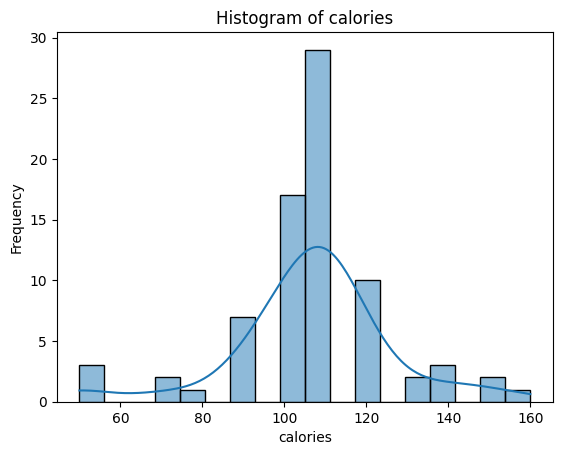

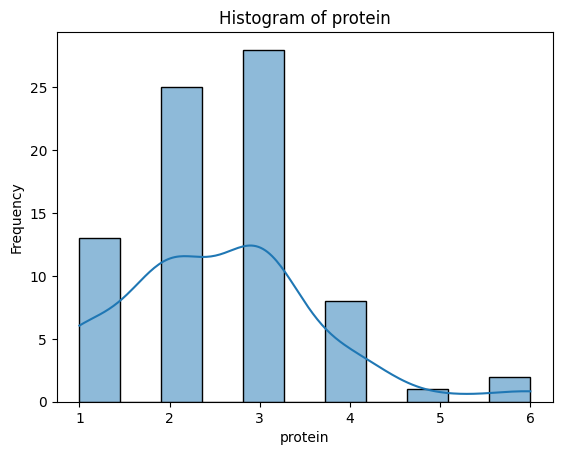

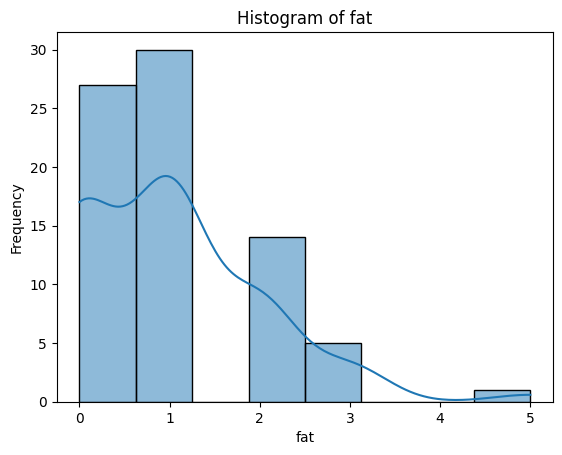

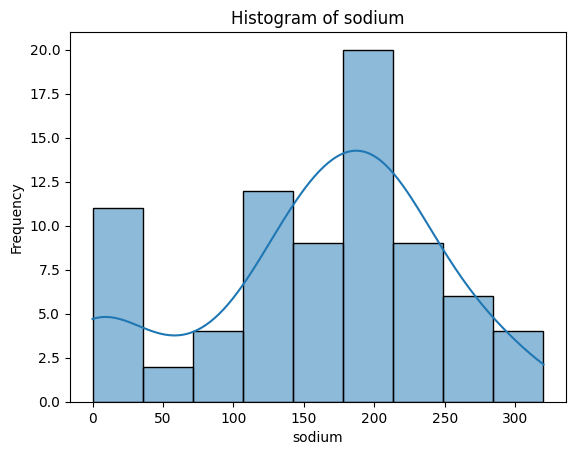

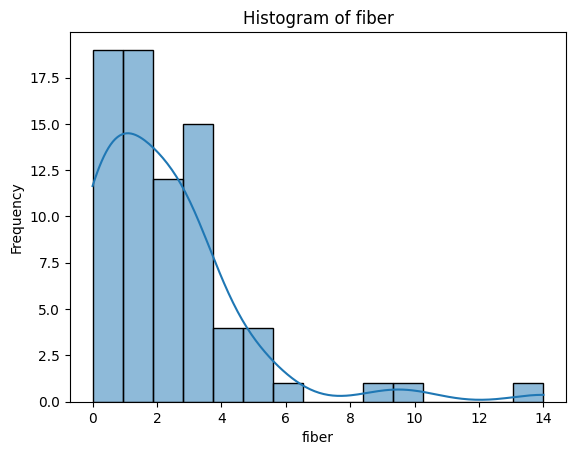

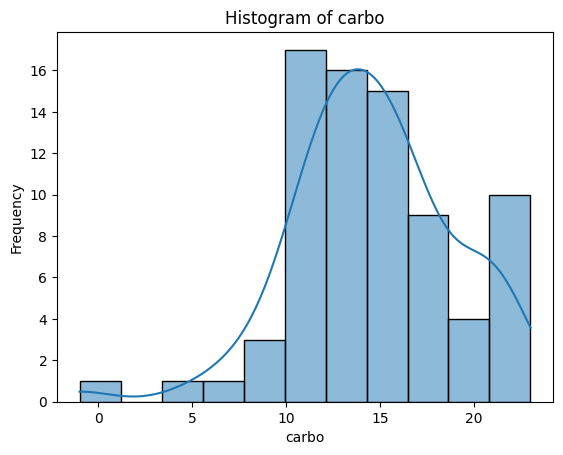

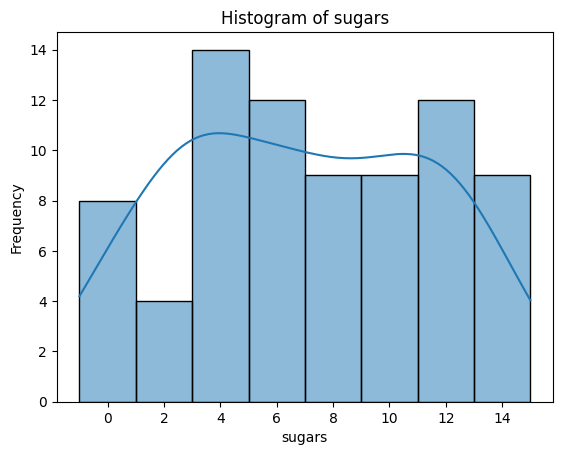

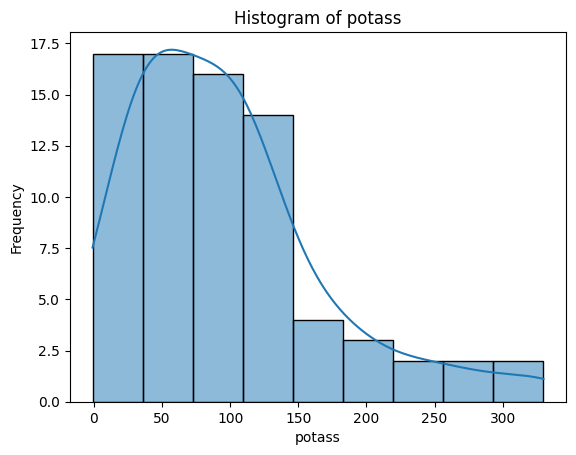

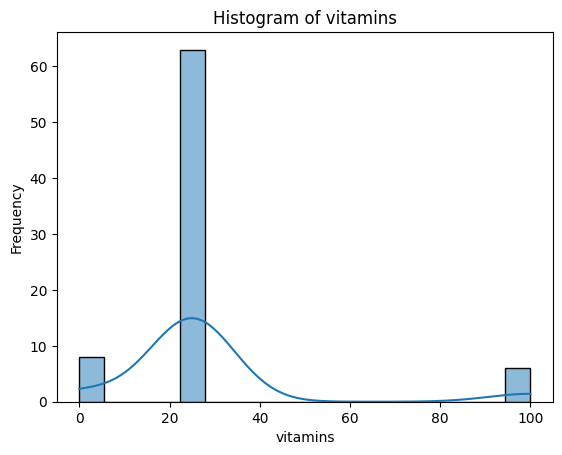

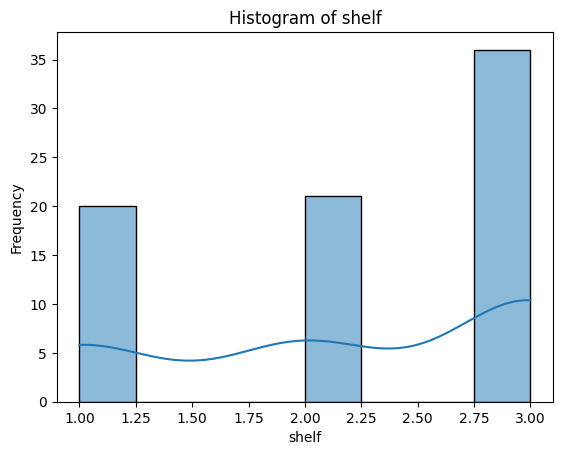

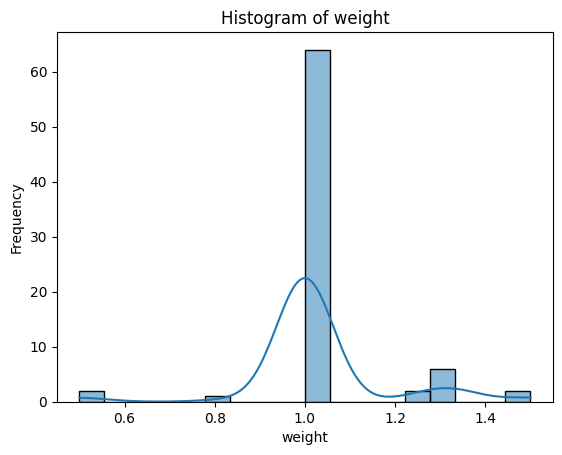

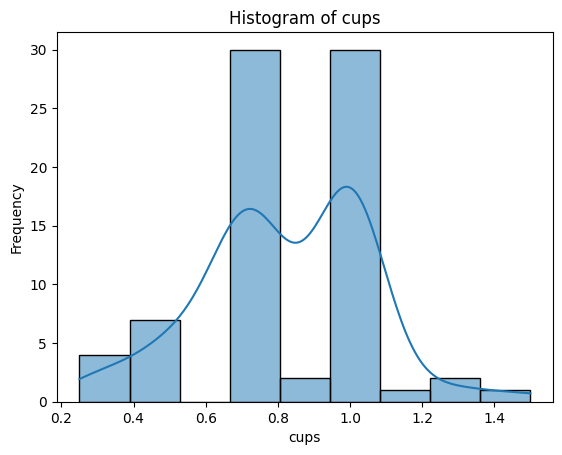

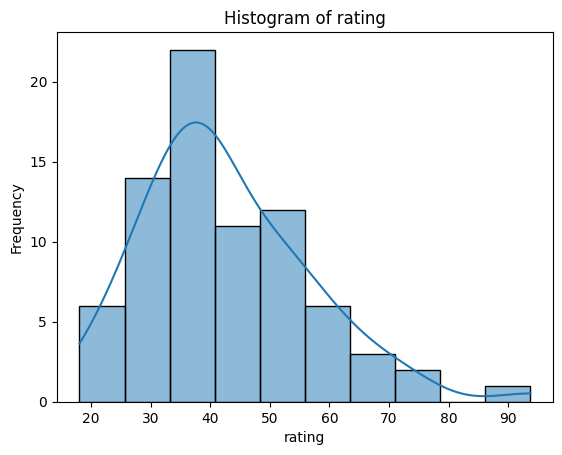

In [6]:
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

7. Create a pair plot using Seaborn to visualize the relationships between all numerical
columns.

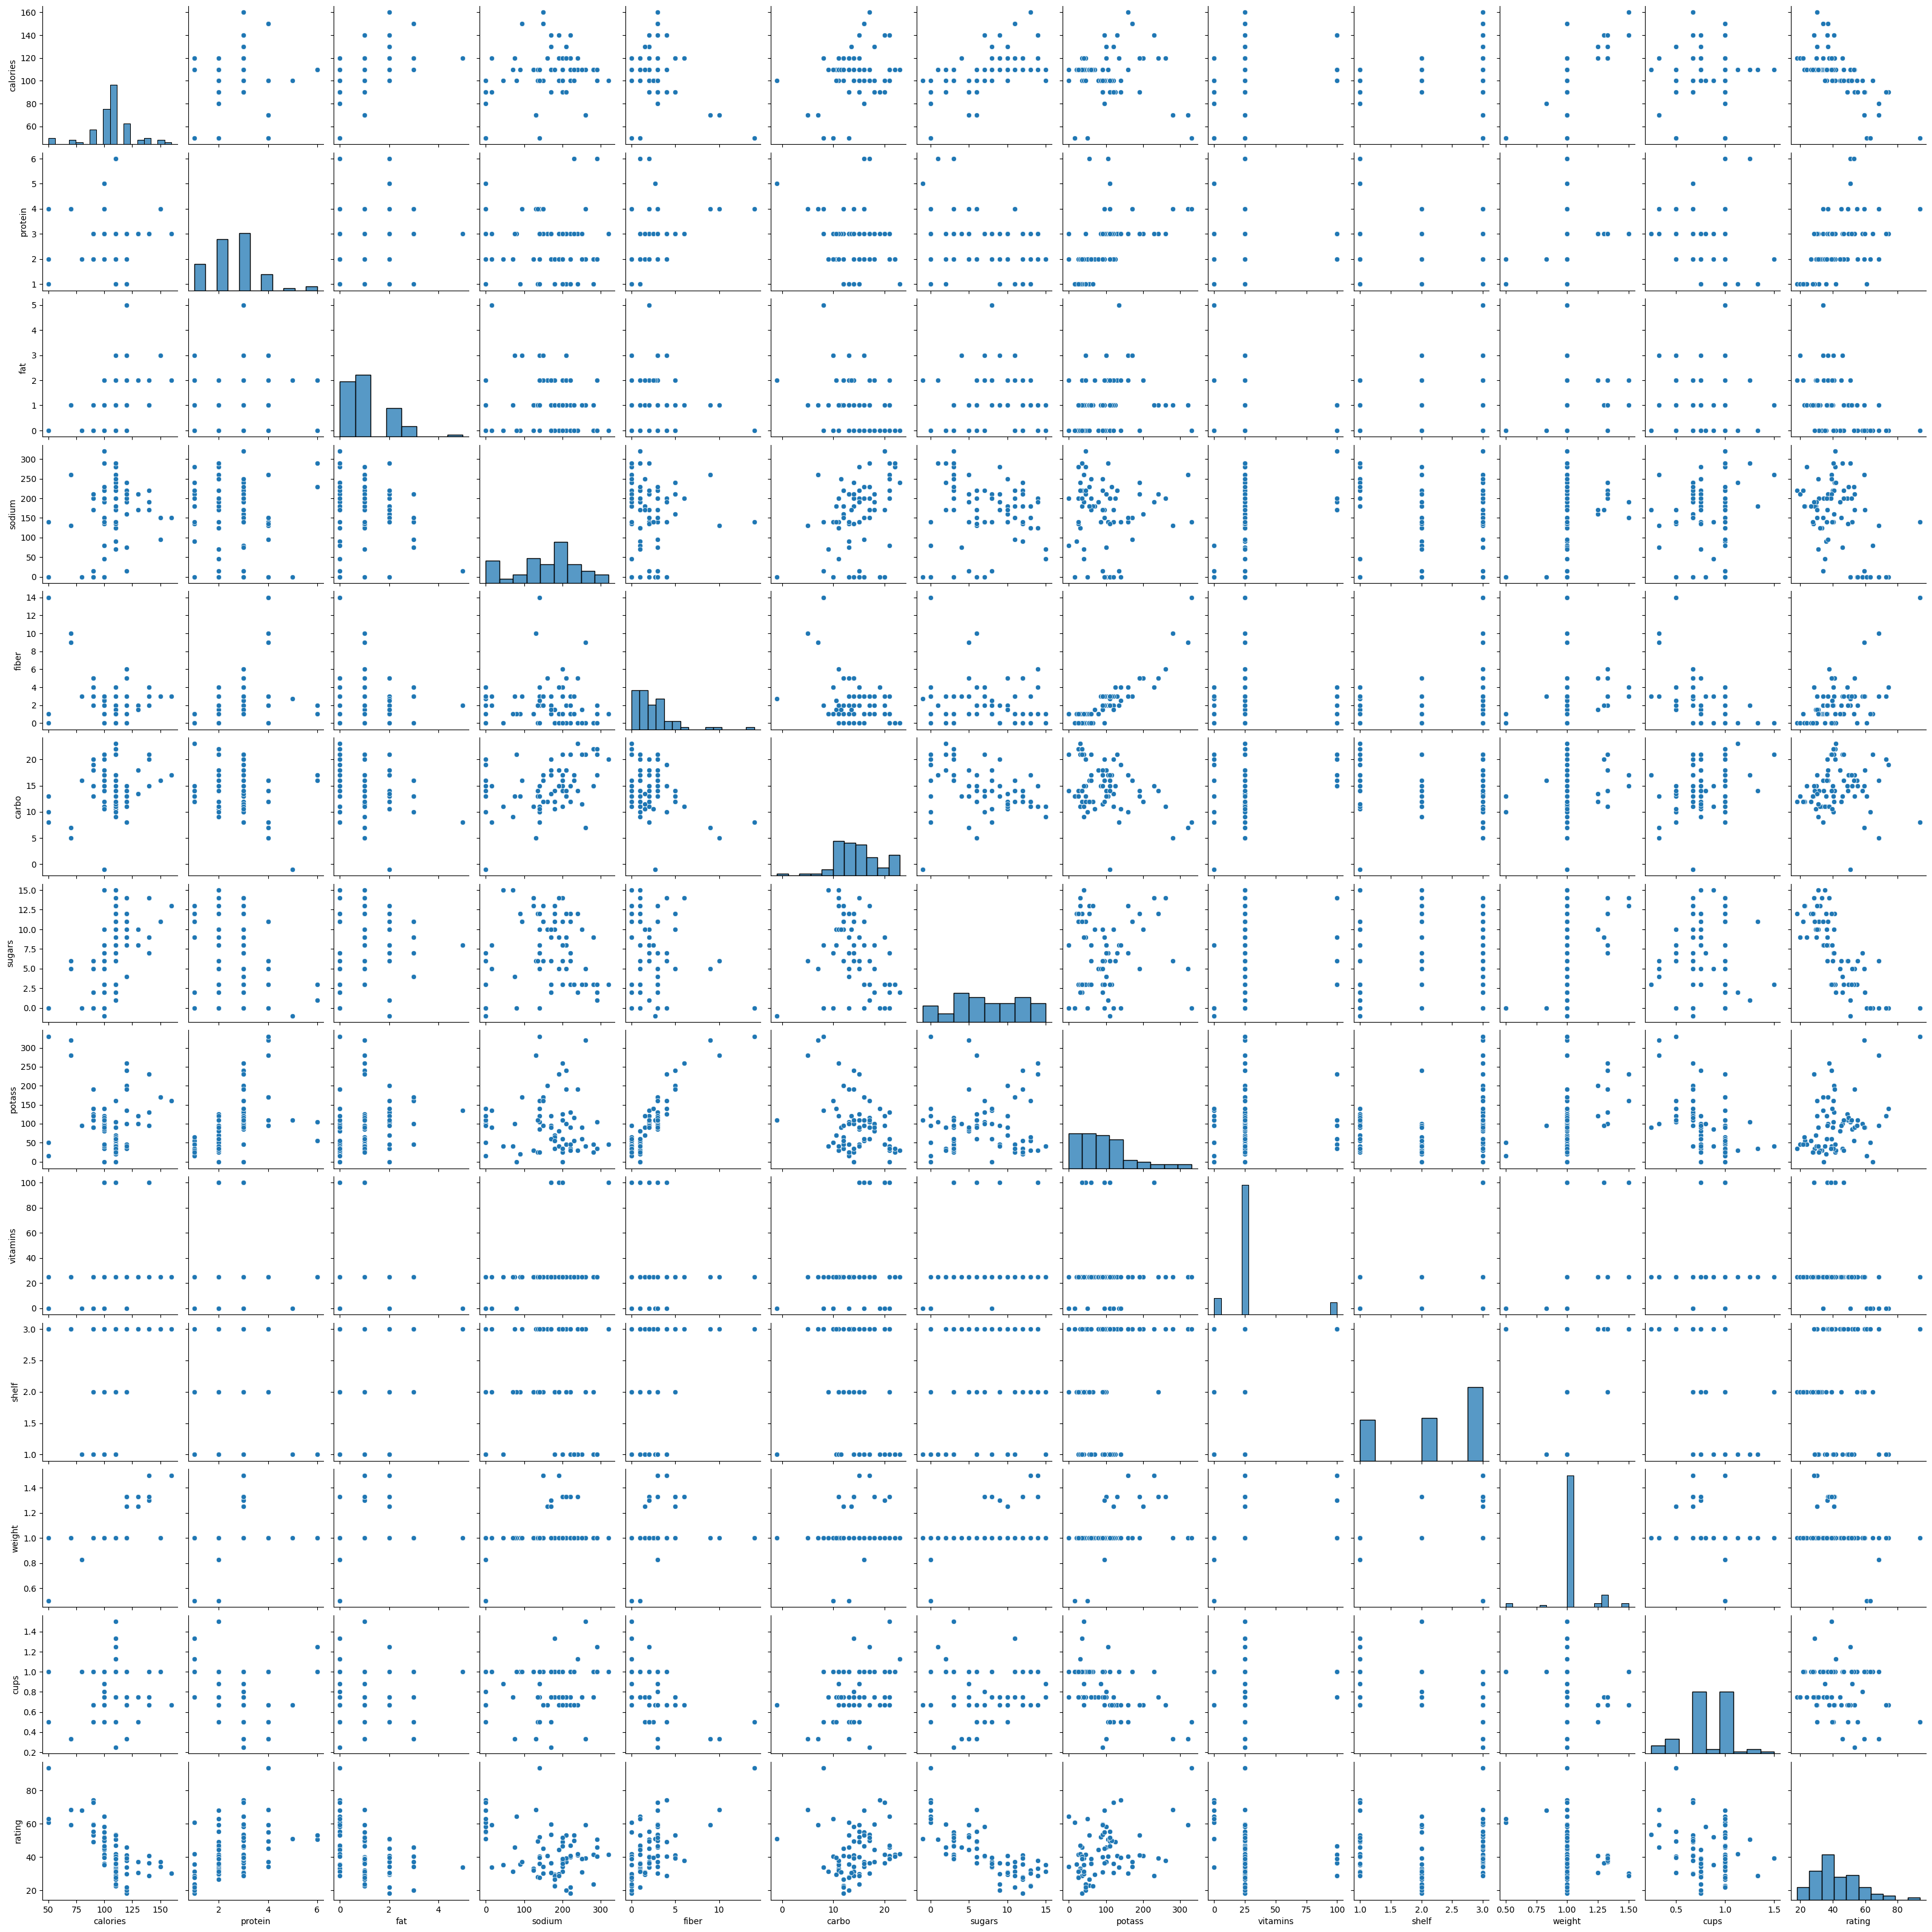

In [7]:
sns.pairplot(df[numerical_cols])
plt.show()

8. Investigate statistical key insights of the numerical columns such as mean, median, stan-
dard deviation, and quartiles (via `.describe()`).

In [8]:
df.describe()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.545455,1.012987,159.675325,2.151948,14.597403,6.922078,96.077922,28.246753,2.207792,1.029610,0.821039,42.665705
std,19.484119,1.094790,1.006473,83.832295,2.383364,4.278956,4.444885,71.286813,22.342523,0.832524,0.150477,0.232716,14.047289
min,50.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,40.000000,25.000000,1.000000,1.000000,0.670000,33.174094
50%,110.000000,3.000000,1.000000,180.000000,2.000000,14.000000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.400208
75%,110.000000,3.000000,2.000000,210.000000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.828392
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


9. Calculate the correlation matrix for the numerical columns.

In [9]:
corr_matrix = df[numerical_cols].corr()
print("Correlation matrix:\n", corr_matrix)

Correlation matrix:
           calories   protein       fat    sodium     fiber     carbo  \
calories  1.000000  0.019066  0.498610  0.300649 -0.293413  0.250681   
protein   0.019066  1.000000  0.208431 -0.054674  0.500330 -0.130864   
fat       0.498610  0.208431  1.000000 -0.005407  0.016719 -0.318043   
sodium    0.300649 -0.054674 -0.005407  1.000000 -0.070675  0.355983   
fiber    -0.293413  0.500330  0.016719 -0.070675  1.000000 -0.356083   
carbo     0.250681 -0.130864 -0.318043  0.355983 -0.356083  1.000000   
sugars    0.562340 -0.329142  0.270819  0.101451 -0.141205 -0.331665   
potass   -0.066609  0.549407  0.193279 -0.032603  0.903374 -0.349685   
vitamins  0.265356  0.007335 -0.031156  0.361477 -0.032243  0.258148   
shelf     0.097234  0.133865  0.263691 -0.069719  0.297539 -0.101790   
weight    0.696091  0.216158  0.214625  0.308576  0.247226  0.135136   
cups      0.087200 -0.244469 -0.175892  0.119665 -0.513061  0.363932   
rating   -0.689376  0.470618 -0.409284 -0.4

10. Visualize the correlation matrix using a heatmap.

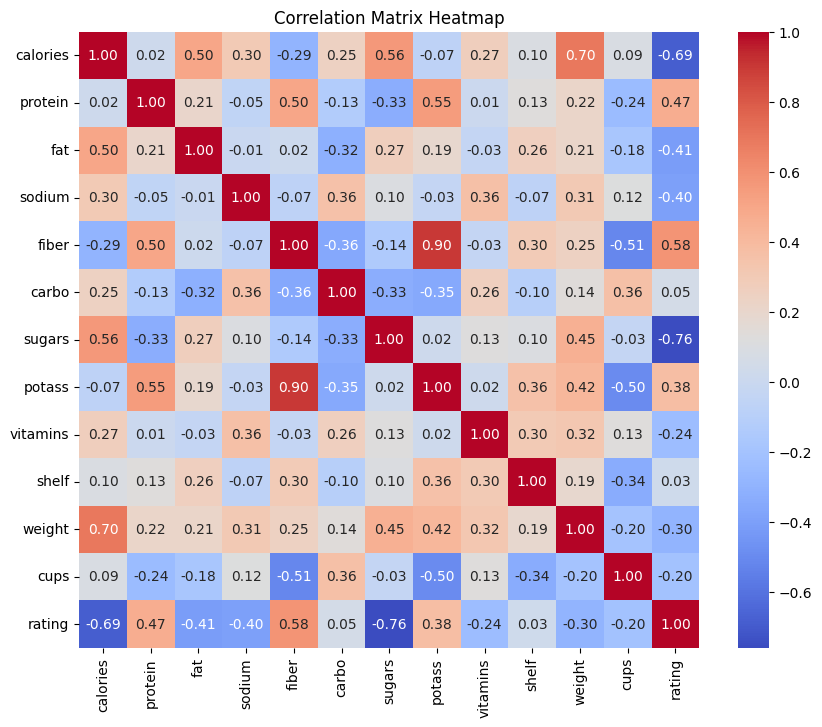

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

### Manual Image Data Cleaning with Thumbnail View and Resolution Analysis

1. Use an image viewing program of your choice that supports thumbnail views to display the images in the directory.
2. Review the following criteria for each image in the thumbnail view:
    - **Resolution and Sharpness:** Are the images in the thumbnail view sufficiently
    sharp and clearly recognizable?
    - **Object:** Is the object (Chihuahua or muffin) clearly recognizable in the thumbnail
    view?
    - **Realism:** Is it a real photo and not a drawing or cartoon? We only want real photos.
3. Remove all images that do not meet the above criteria directly from the directory.
4. Create a list of all remaining image files in the directory using Python and display the number of images.
5. Count how many different resolutions exist in the two folders and rescale/transform all in the same size and save them in new folders.

In [11]:
import os
from PIL import Image

base_image_dir = "Aux/chihuahua-muffin/Filtered"
folders = [f for f in os.listdir(base_image_dir) if os.path.isdir(os.path.join(base_image_dir, f))]

def get_image_files(directory):
    return [f for f in os.listdir(directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))]

def files_to_paths(directory, files):
    return [os.path.join(directory, f) for f in files]

def analyze_resolutions(image_paths):
    resolutions = {}
    for image_path in image_paths:
        try:
            with Image.open(image_path) as img:
                resolutions[img.size] = resolutions.get(img.size, 0) + 1
        except Exception as e:
            print(f"Error opening {image_path}: {e}")
    return resolutions

def analyze_proportions(resolutions):
    proportions = {}
    for width, height in resolutions:
        prop = width / height if height != 0 else 0
        proportions[prop] = proportions.get(prop, 0) + 1
    return proportions

def analyze_image_modes(image_paths):
    modes = {}
    for image_path in image_paths:
        try:
            with Image.open(image_path) as img:
                modes[img.mode] = modes.get(img.mode, 0) + 1
        except Exception as e:
            print(f"Error opening {image_path}: {e}")
    return modes

def rescale_images(image_paths, dest_dir, target_resolution):
    os.makedirs(dest_dir, exist_ok=True)
    for image_path in image_paths:
        try:
            with Image.open(image_path) as img:
                img_rescaled = img.resize(target_resolution)
                original_format = img.format
                basename_without_ext = os.path.splitext(os.path.basename(image_path))[0]
                new_filename = f"{basename_without_ext}_rescaled.{original_format.lower()}"
                img_rescaled.save(os.path.join(dest_dir, new_filename))
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            print(f"Original resolution: {img.size}, Rescaled resolution: {target_resolution}")
            print(f"Original mode: {img.mode}, Rescaled mode: {img_rescaled.mode}")
            print(f"Original format: {img.format}, Rescaled format: {img_rescaled.format}")


for folder in folders:
    print(f"\n--- Analyzing folder: {folder} ---")
    image_files = get_image_files(os.path.join(base_image_dir, folder))
    print(f"Number of images in '{folder}': {len(image_files)}")
    print(f"Sample image files in '{folder}' (first 5):", image_files[:5])

    print(f"\n--- Resolution analysis for '{folder}' ---")
    image_paths = files_to_paths(os.path.join(base_image_dir, folder), image_files)
    resolutions = analyze_resolutions(image_paths)
    print(f"Number of different resolutions in '{folder}': {len(resolutions)}")
    print("Resolution distribution:")
    for res, count in resolutions.items():
        print(f"- {res}: {count} images")

    print(f"\n--- Proportion analysis for '{folder}' ---")
    proportions = analyze_proportions(resolutions)
    print(f"Number of different proportions in '{folder}': {len(proportions)}")
    print("Proportion distribution:")
    for prop, count in proportions.items():
        print(f"- {prop:.2f}: {count} images")

    print(f"\n--- Image mode analysis for '{folder}' ---")
    modes = analyze_image_modes(image_paths)
    print(f"Number of different image modes in '{folder}': {len(modes)}")
    print("Image mode distribution:")
    for mode, count in modes.items():
        print(f"- {mode}: {count} images")

    print(f"\n--- Rescaling images in '{folder}' ---")
    output_dir = os.path.join(base_image_dir.replace("Filtered", "Rescaled"), folder)
    target_weight = 224
    mean_proportion = 0
    for prop, count in proportions.items():
        mean_proportion += prop * count
    mean_proportion /= sum(proportions.values())
    target_resolution = (target_weight, int(target_weight*mean_proportion))
    print(f"Rescaling images to target resolution: {target_resolution}")
    rescale_images(image_paths, output_dir, target_resolution)




--- Analyzing folder: muffin ---
Number of images in 'muffin': 500
Sample image files in 'muffin' (first 5): ['muffin_444.JPG', 'muffin_105.JPG', 'muffin_244.JPG', 'muffin_66.JPG', 'muffin_13.JPG']

--- Resolution analysis for 'muffin' ---
Number of different resolutions in 'muffin': 200
Resolution distribution:
- (3948, 5922): 1 images
- (330, 333): 1 images
- (402, 612): 1 images
- (612, 430): 1 images
- (240, 240): 6 images
- (612, 408): 141 images
- (360, 240): 44 images
- (466, 612): 1 images
- (612, 406): 9 images
- (176, 167): 1 images
- (612, 602): 1 images
- (612, 459): 12 images
- (435, 612): 1 images
- (361, 240): 6 images
- (183, 185): 1 images
- (222, 182): 1 images
- (199, 190): 1 images
- (612, 390): 1 images
- (174, 195): 1 images
- (168, 171): 1 images
- (408, 612): 28 images
- (168, 169): 1 images
- (612, 229): 1 images
- (612, 309): 2 images
- (495, 612): 1 images
- (612, 407): 8 images
- (160, 240): 5 images
- (459, 612): 6 images
- (4000, 6000): 5 images
- (160, 1